In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# IMPORTAMOS LIBREARIAS PARA KMEANS

In [2]:
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from yellowbrick.cluster import SilhouetteVisualizer

# GENERAMOS DATOS ALEATORIOS PARA EL EJEMPLO con MAKE_BLOBS

In [3]:
X,y,c = make_blobs(500,cluster_std=0.8,centers=4,n_features=2,return_centers=True)

# CREO DATAFRAME CON CENTROIDES

In [4]:
df_blobs = pd.DataFrame(
    {
        'x1':X[:,0],
        'x2':X[:,1],
        'y':y
    }
)
df_blobs

,x1,x2,y
0,-2.327323,-1.057328,3
1,5.524802,-3.698824,2
2,6.286889,-8.976094,0
3,3.975279,-2.401073,2
4,7.636003,7.708143,1
...,...,...,...
495,7.926546,-9.344197,0
496,-1.631673,0.781850,3
497,7.500851,7.616016,1
498,6.009285,-8.886714,0


In [5]:
df_centers = pd.DataFrame(
    {
        'x1':c[:,0],
        'x2':c[:,1]
    }
)
df_centers

,x1,x2
0,6.540408,-9.457743
1,7.054396,8.037006
2,5.010299,-2.160205
3,-2.199014,-0.521805


# GRAFICAMOS LOS DATOS

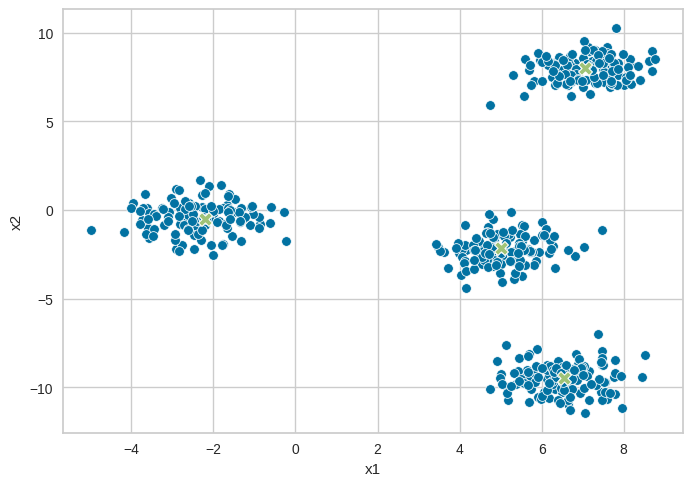

In [6]:
sns.scatterplot(data=df_blobs,x='x1',y='x2')
sns.scatterplot(data=df_centers,x='x1',y='x2',marker='X',s=100)
plt.show()

# APLICAMOS K-MEANS

In [7]:
kmeans = KMeans(n_clusters=4)
df_cluster = kmeans.fit_predict(X)
df_blobs['cluster'] = df_cluster
df_blobs

,x1,x2,y,cluster
0,-2.327323,-1.057328,3,3
1,5.524802,-3.698824,2,1
2,6.286889,-8.976094,0,2
3,3.975279,-2.401073,2,1
4,7.636003,7.708143,1,0
...,...,...,...,...
495,7.926546,-9.344197,0,2
496,-1.631673,0.781850,3,3
497,7.500851,7.616016,1,0
498,6.009285,-8.886714,0,2


In [8]:
k_means_centers = kmeans.cluster_centers_
df_k_means_center = pd.DataFrame(
    {
        'x1':k_means_centers[:,0],
        'x2':k_means_centers[:,1]
    }
)
df_k_means_center

,x1,x2
0,7.095181,7.983523
1,5.054581,-2.250831
2,6.464293,-9.497165
3,-2.379825,-0.426693


# GRAFICAMOS LOS RESULTADOS DE K-MEANS

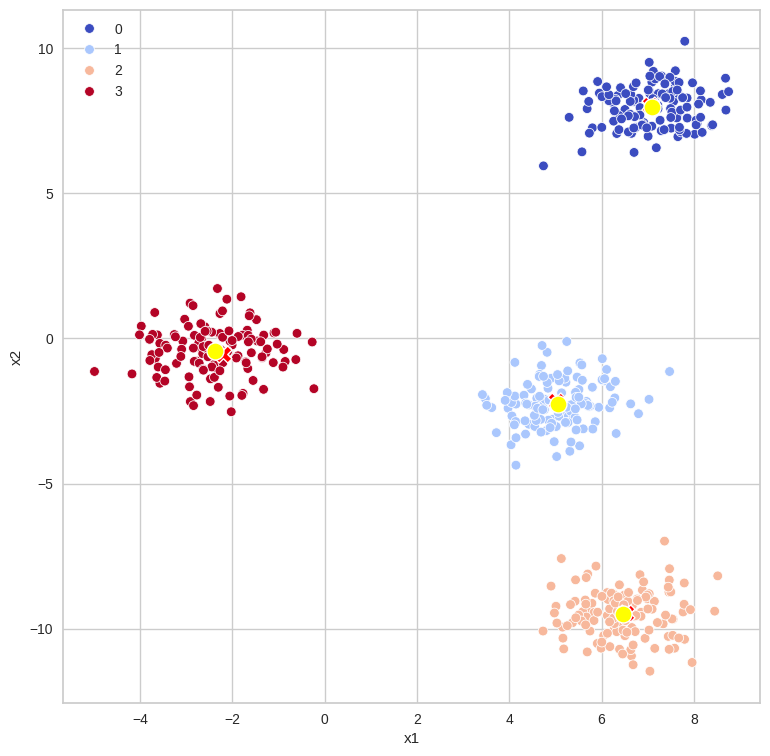

In [9]:
fig = plt.figure(figsize=(9,9))
sns.scatterplot(data=df_blobs,x='x1',y='x2',hue='cluster',palette='coolwarm')
sns.scatterplot(data=df_centers,  x='x1', y='x2', marker='X', s=150 , color='red')
sns.scatterplot(data=df_k_means_center,  x='x1', y='x2', marker='o', s=150 , color='yellow')
plt.show()